# Iris Flower Classification

**Project:** Iris Flower Classification

**Objective:** Build and evaluate machine learning models to classify Iris flowers into Setosa, Versicolor, and Virginica based on their morphological features.

## 1. Import Required Libraries

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Visualization Style
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully.


## 2. Load the Dataset

In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target labels
df["species"] = iris.target

# Convert numeric labels into species names
species_mapping = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

df["species"] = df["species"].map(species_mapping)

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


## 3. Exploratory Data Analysis (EDA)

In [3]:
# Display basic information about the dataset
print("Dataset Shape:", df.shape)

print("\nFeature Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

Dataset Shape: (150, 5)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']

Data Types:


sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object


Missing Values:


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


Duplicate Records:
1


In [4]:
# Statistical summary of numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.057333,0.435866,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.758000,1.765298,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.199333,0.762238,0.1,0.3,1.30,1.8,2.5


In [5]:
# Display a random sample of records
df.sample(10, random_state=42)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
73,6.1,2.8,4.7,1.2,Versicolor
18,5.7,3.8,1.7,0.3,Setosa
118,7.7,2.6,6.9,2.3,Virginica
78,6.0,2.9,4.5,1.5,Versicolor
76,6.8,2.8,4.8,1.4,Versicolor
31,5.4,3.4,1.5,0.4,Setosa
64,5.6,2.9,3.6,1.3,Versicolor
141,6.9,3.1,5.1,2.3,Virginica
68,6.2,2.2,4.5,1.5,Versicolor
82,5.8,2.7,3.9,1.2,Versicolor


## 4. Data Visualization

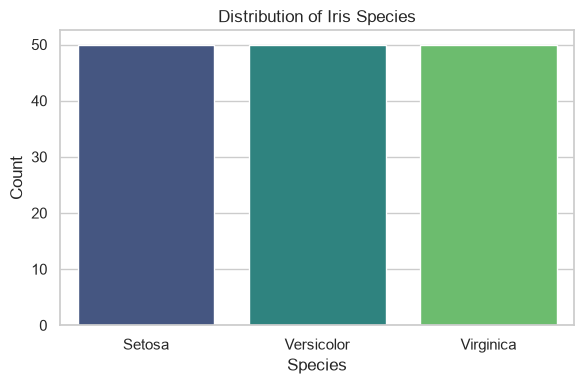

In [6]:
# Class Distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="species",
    palette="viridis"
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

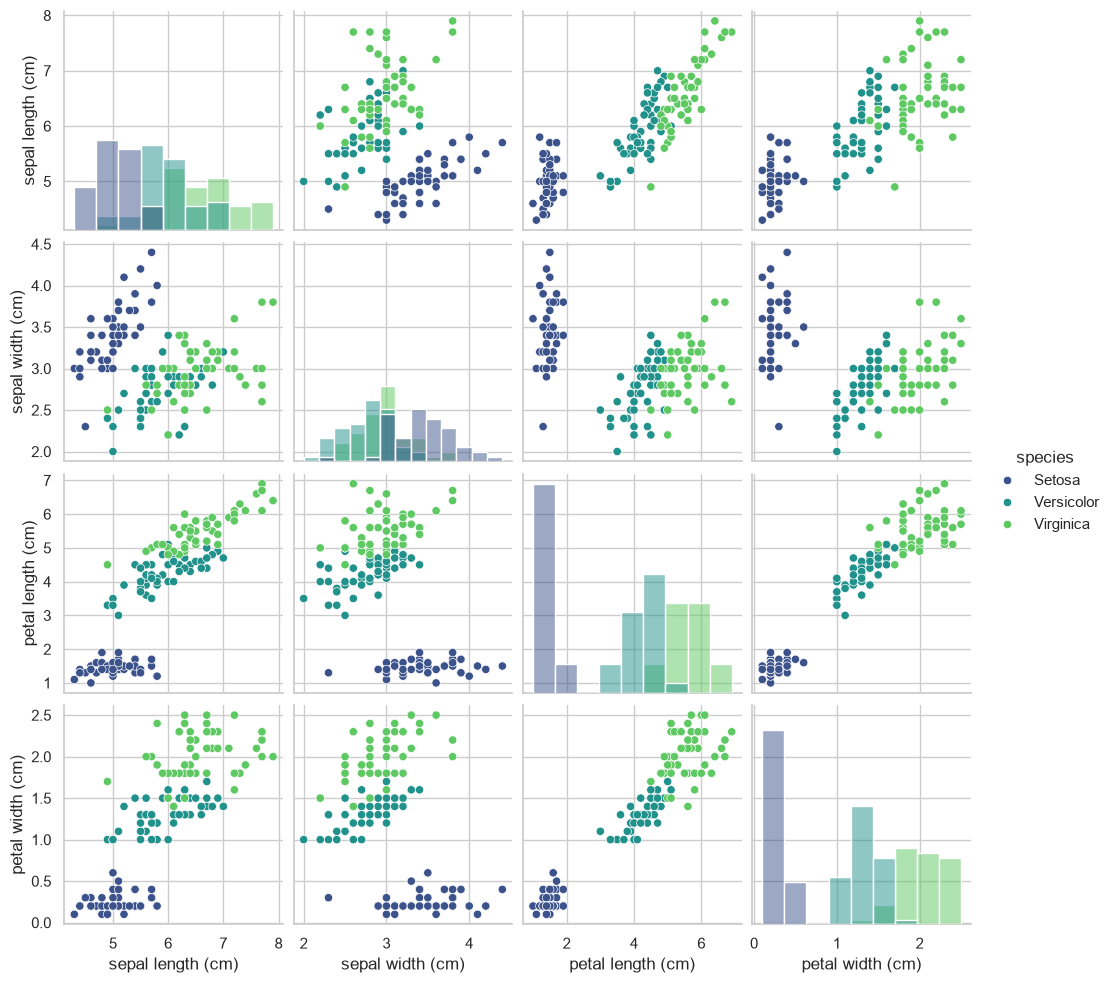

In [7]:
# Pair Plot
sns.pairplot(
    df,
    hue="species",
    palette="viridis",
    diag_kind="hist"
)

plt.show()

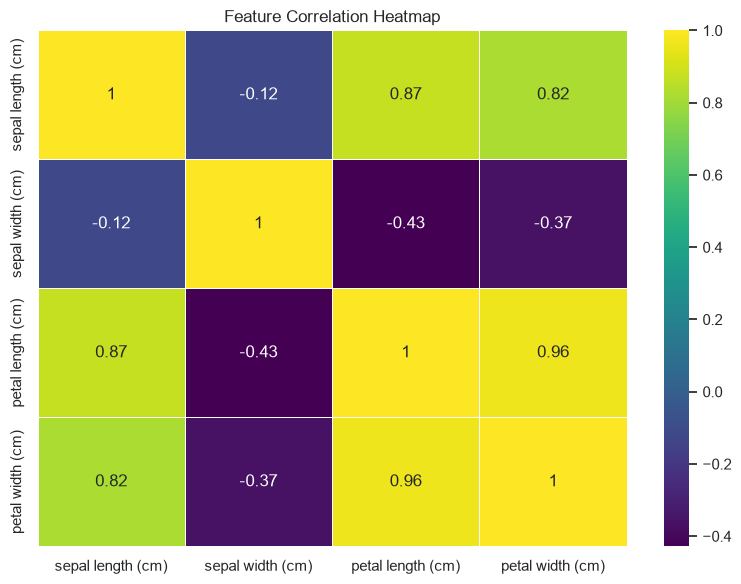

In [8]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

numeric_df = df.drop(columns=["species"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="viridis",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

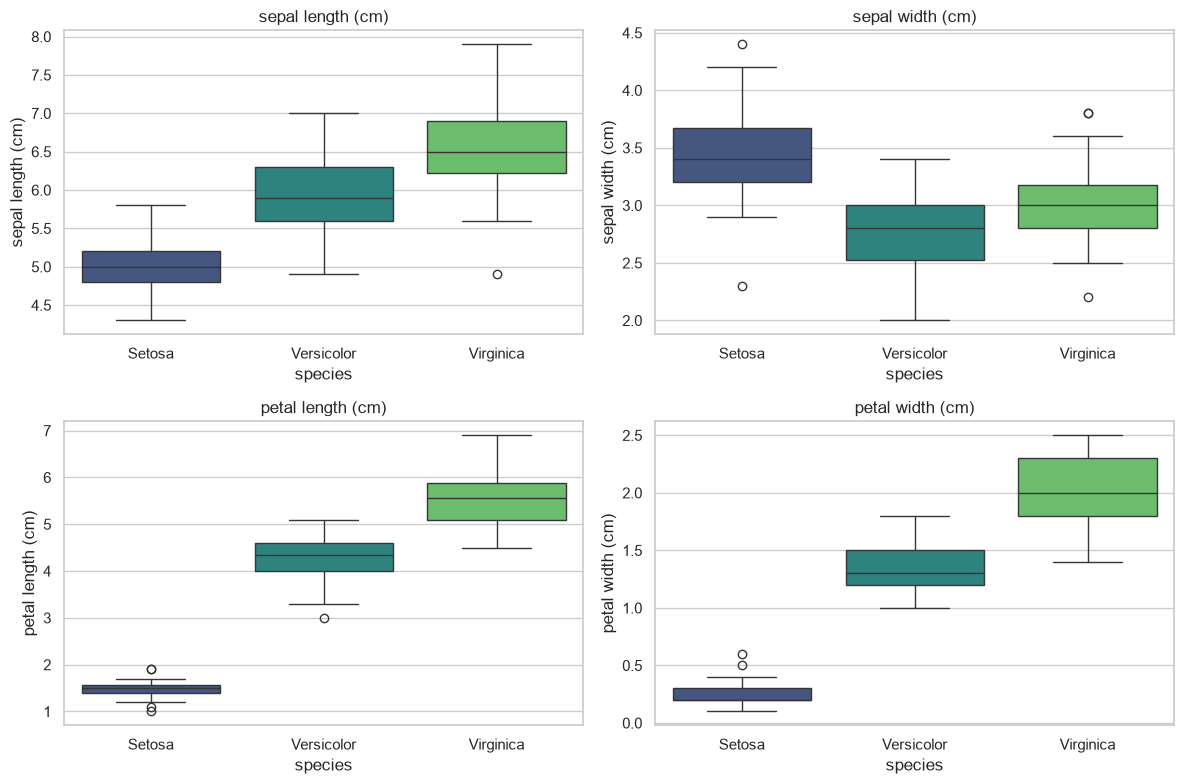

In [9]:
# Box Plots

fig, axes = plt.subplots(2, 2, figsize=(12,8))

columns = numeric_df.columns

for ax, column in zip(axes.flatten(), columns):
    sns.boxplot(
        data=df,
        x="species",
        y=column,
        palette="viridis",
        ax=ax
    )
    ax.set_title(column)

plt.tight_layout()
plt.show()

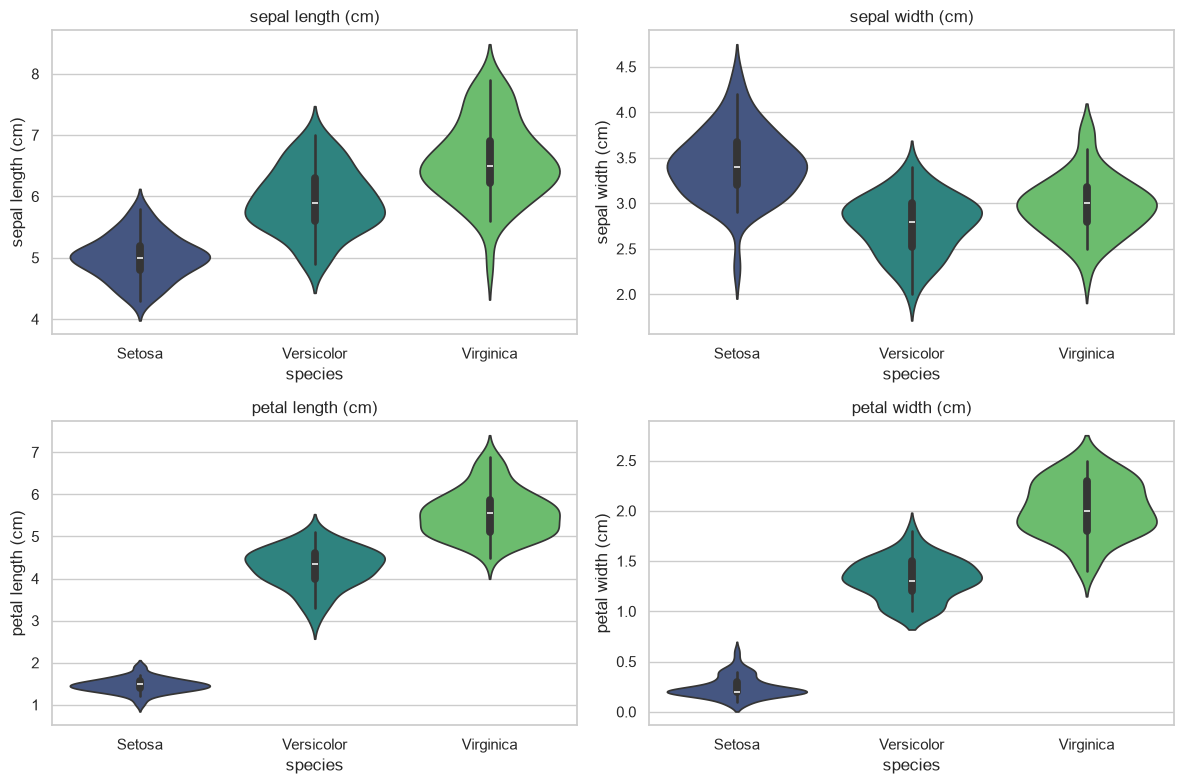

In [10]:
# Violin Plots

fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, column in zip(axes.flatten(), columns):
    sns.violinplot(
        data=df,
        x="species",
        y=column,
        palette="viridis",
        ax=ax
    )
    ax.set_title(column)

plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [11]:
# Features and Target

X = df.drop("species", axis=1)
y = df["species"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (150, 4)
Target Shape   : (150,)


In [12]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 120
Testing Samples  : 30


In [13]:
# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


## 6. Model Training

In [14]:
# Initialize Classification Models

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

print("Models initialized successfully.")

Models initialized successfully.


In [15]:
# Train Models

trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

print("All models trained successfully.")

All models trained successfully.


In [16]:
# Generate Predictions

predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_scaled)

print("Predictions generated successfully.")

Predictions generated successfully.


## 7. Model Evaluation

In [17]:
# Calculate Accuracy Scores

accuracy_results = {}

for name, prediction in predictions.items():
    accuracy = accuracy_score(y_test, prediction)
    accuracy_results[name] = accuracy

accuracy_df = (
    pd.DataFrame(
        accuracy_results.items(),
        columns=["Model", "Accuracy"]
    )
    .sort_values(by="Accuracy", ascending=False)
    .reset_index(drop=True)
)

accuracy_df

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


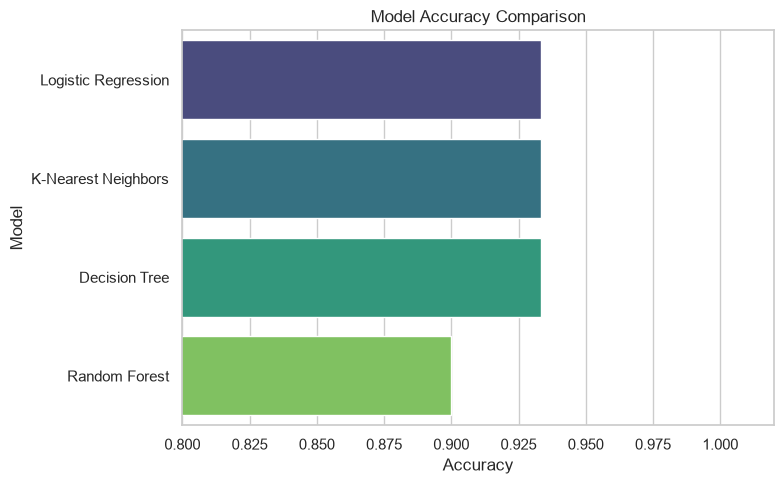

In [18]:
# Accuracy Comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=accuracy_df,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.xlim(0.8,1.02)

plt.tight_layout()

plt.show()

In [19]:
# Display Classification Reports

for name, prediction in predictions.items():
    
    print("="*70)
    print(name)
    print("="*70)

    print(classification_report(y_test, prediction))

Logistic Regression
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

K-Nearest Neighbors
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.83      1.00      0.91        10
   Virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Decision Tree
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.

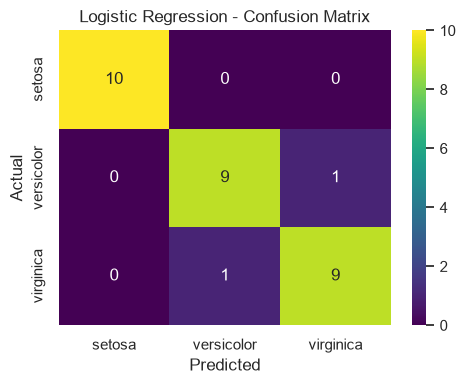

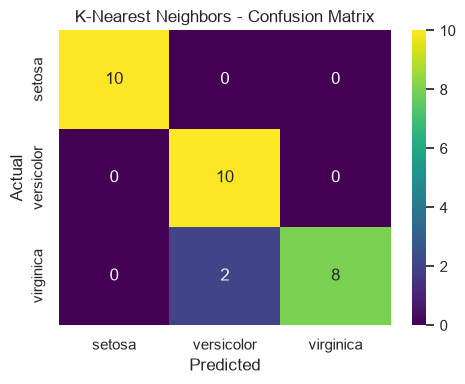

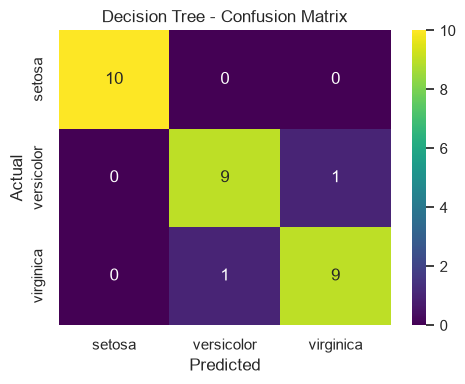

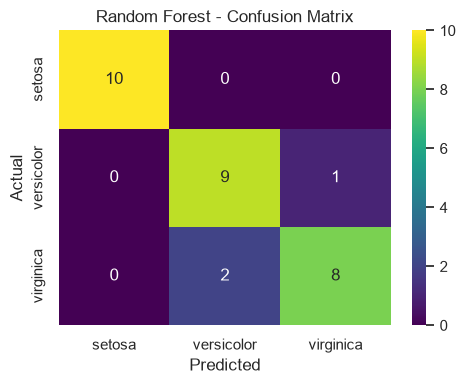

In [20]:
# Confusion Matrices

for name, prediction in predictions.items():

    plt.figure(figsize=(5,4))

    cm = confusion_matrix(y_test, prediction)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

## 8. Model Comparison

In [21]:
accuracy_df.style.highlight_max(
    subset=["Accuracy"],
    color="lightgreen"
)

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbors,0.933333
2,Decision Tree,0.933333
3,Random Forest,0.900000


In [22]:
best_model = accuracy_df.iloc[0]

print("Best Performing Model")
print("----------------------")
print(f"Model    : {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.2%}")

Best Performing Model
----------------------
Model    : Logistic Regression
Accuracy : 93.33%


## 9. Conclusion

## 9. Conclusion

This project successfully developed and evaluated multiple machine learning classification models for predicting Iris flower species based on floral measurements.

### Key Outcomes

- Performed exploratory data analysis to understand feature distributions and class balance.
- Applied feature scaling before model training.
- Trained and evaluated multiple classification algorithms.
- Compared model performance using accuracy, classification reports, and confusion matrices.
- Identified the best-performing model based on evaluation metrics.

The Iris dataset is well-structured, allowing several supervised learning algorithms to achieve excellent predictive performance, demonstrating the effectiveness of classical machine learning techniques for multiclass classification problems.